In [2]:
from google.colab import files
uploaded = files.upload()

Saving master_dataset.xslx.xlsx to master_dataset.xslx.xlsx


Shape of dataset: (27804, 55)

Columns:
 Index(['city', 'date', 'aqi', 'pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3',
       'source', 'objectid', 'oceans', 'regions', 'subregions',
       'sampling_method', 'measurement', 'unit', 'density_range',
       'density_class', 'short_reference', 'long_reference', 'doi',
       'organization', 'keywords', 'accession_number', 'accession_link',
       'latitude', 'longitude', 'globalid', 'x', 'y', 'case_id',
       'date_reported', 'region', 'country', 'pollutant_type',
       'pollutant_concentration_mg_kg', 'soil_ph', 'temperature_c',
       'humidity_%', 'rainfall_mm', 'crop_type', 'farming_practice',
       'nearby_industry', 'water_source_type', 'soil_texture',
       'soil_organic_matter_%', 'disease_type', 'disease_severity',
       'health_symptoms', 'age_group_affected', 'gender_most_affected',
       'mitigation_measure', 'case_resolved', 'follow_up_required'],
      dtype='object')

Correlation Matrix:
                                   

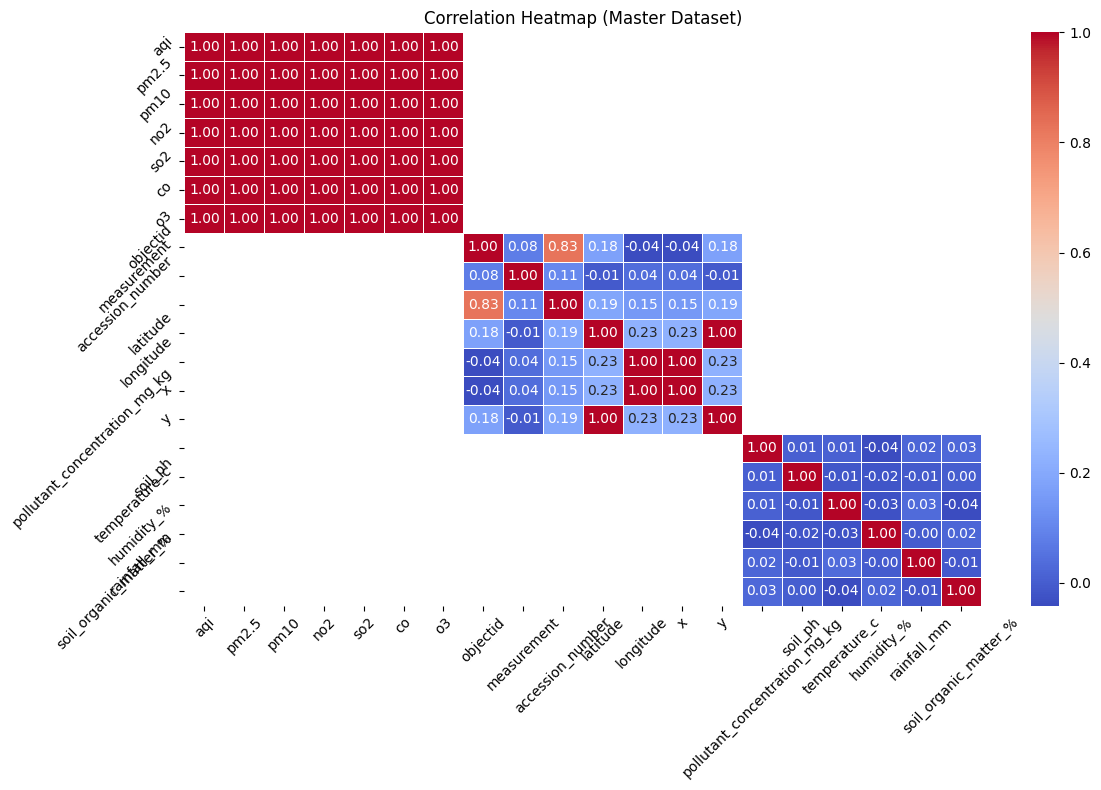

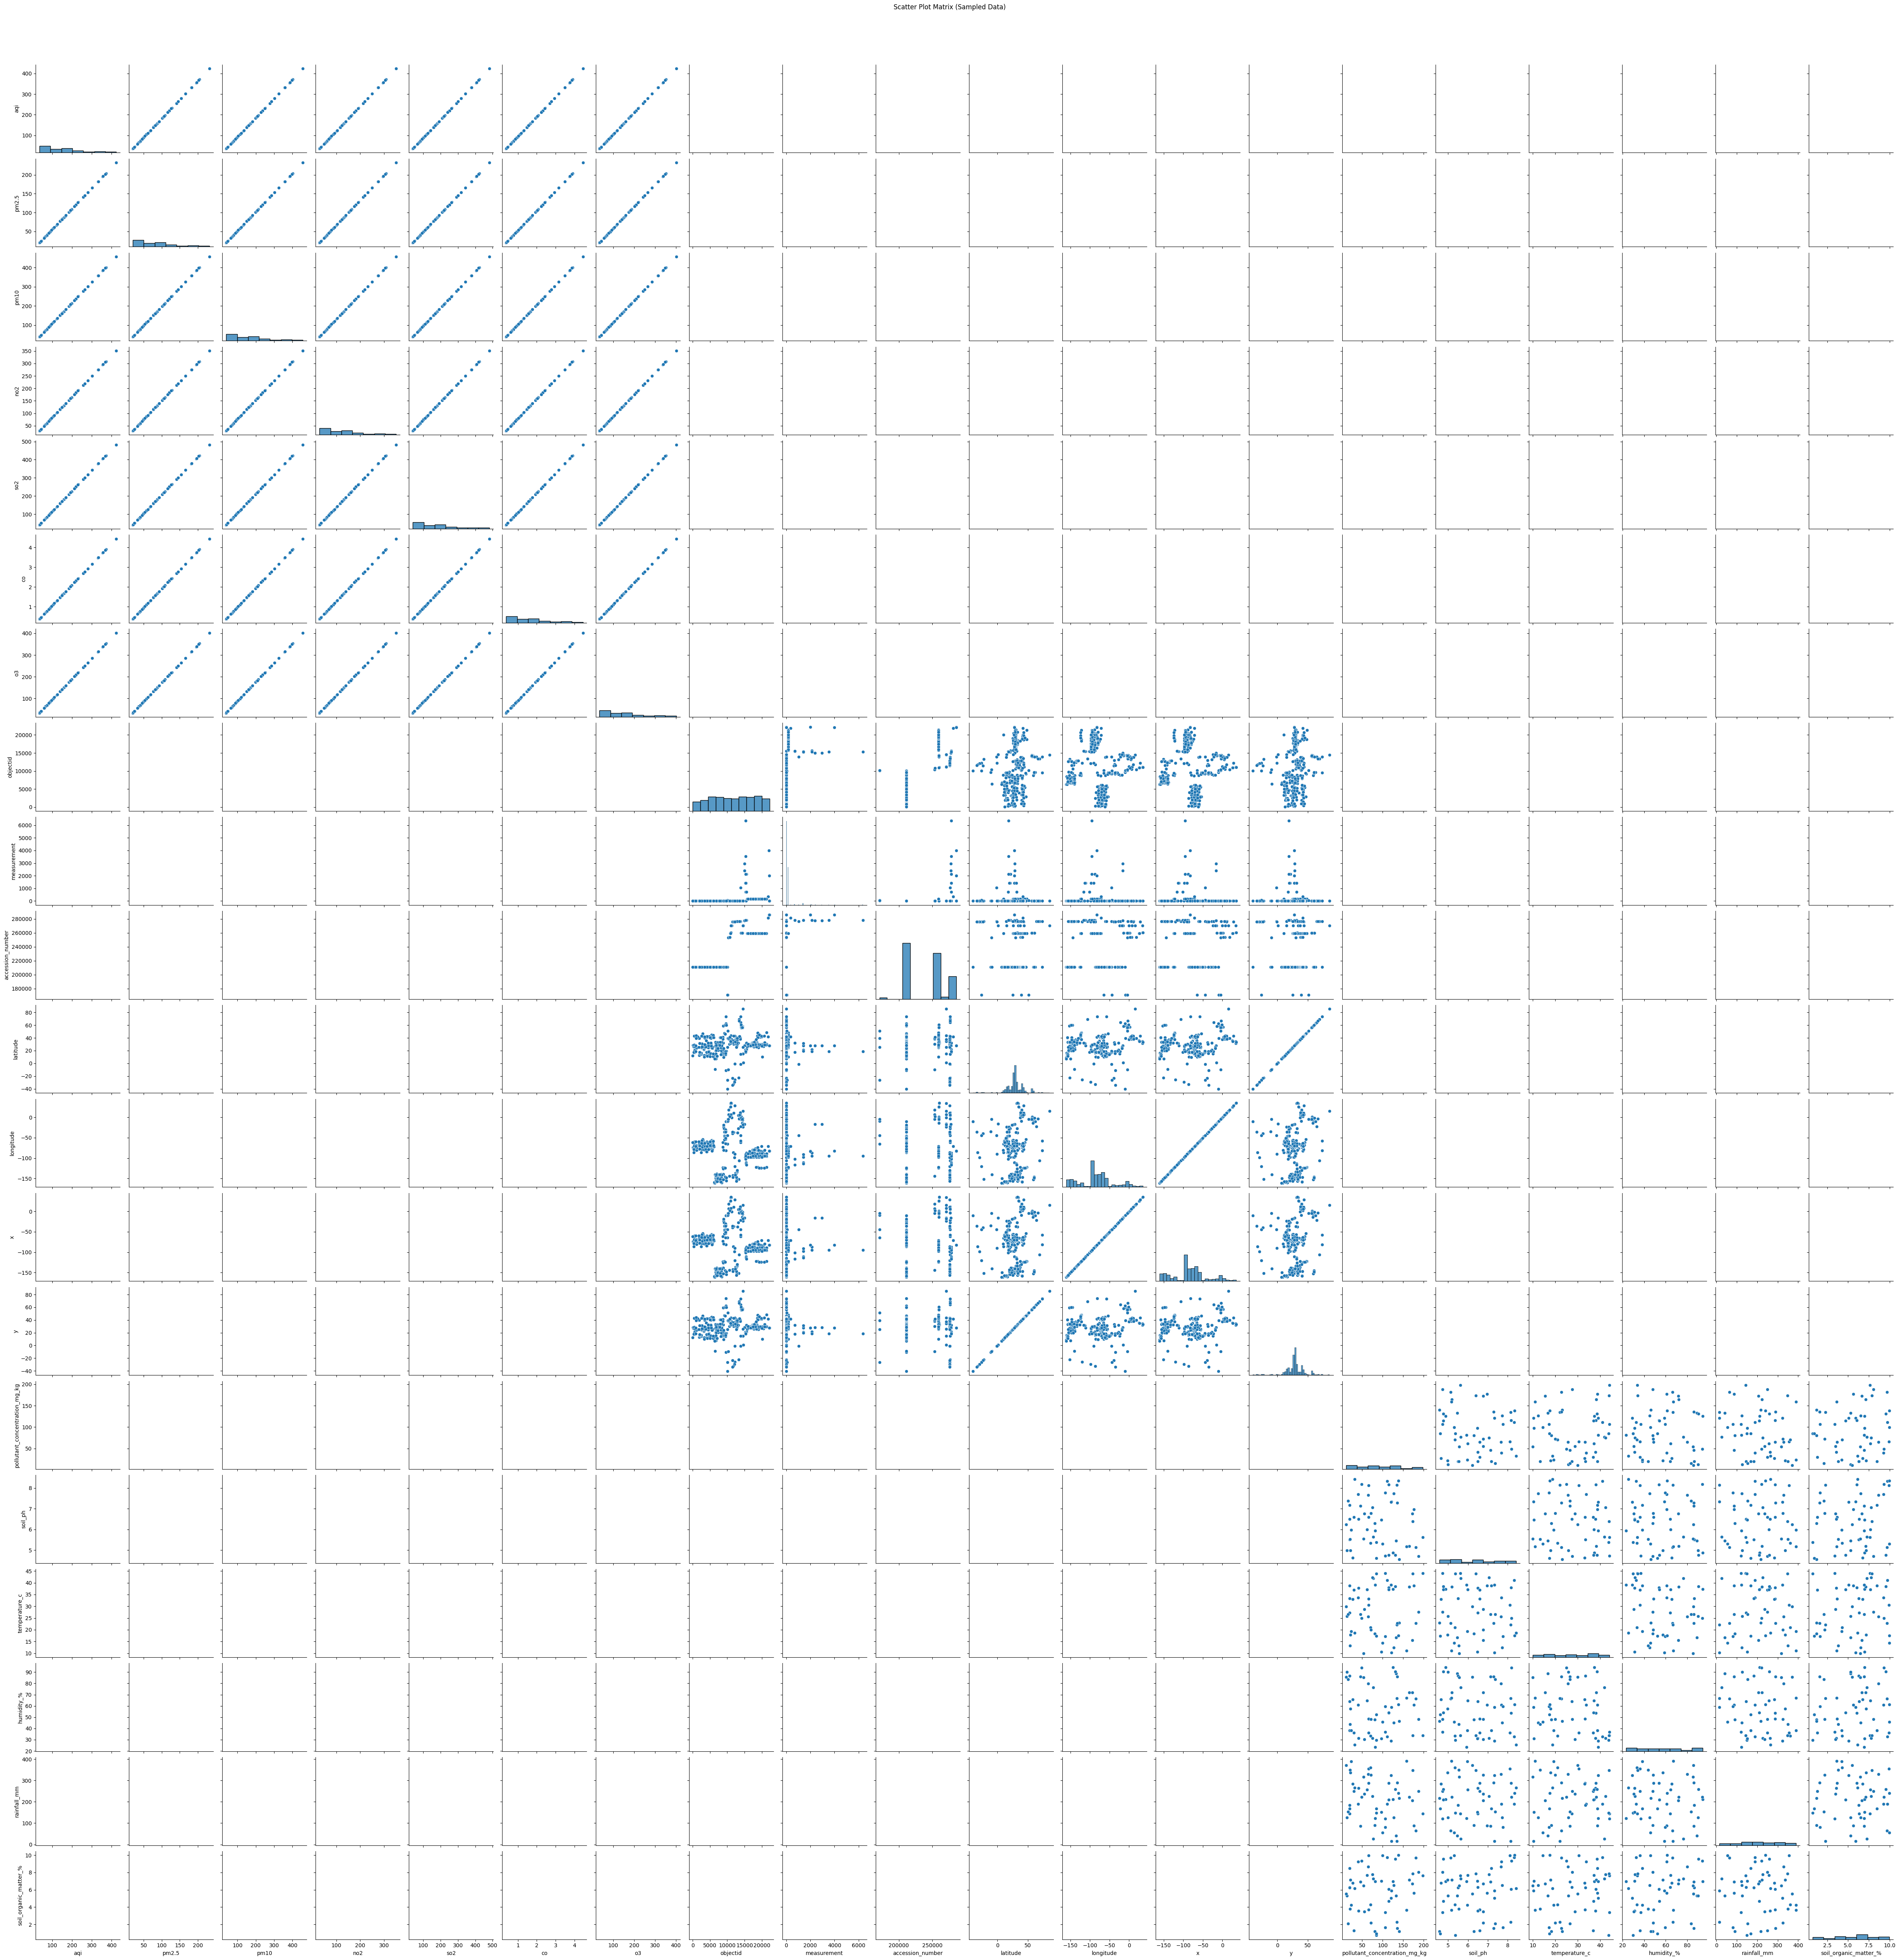

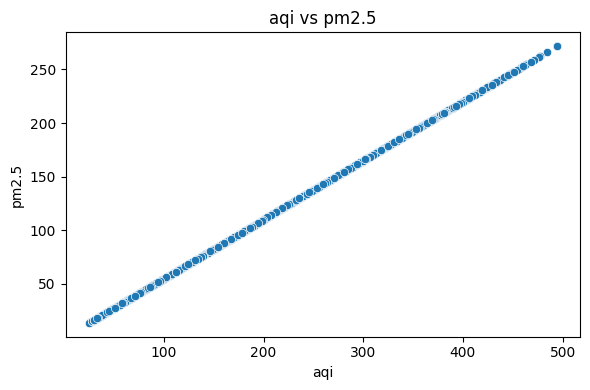

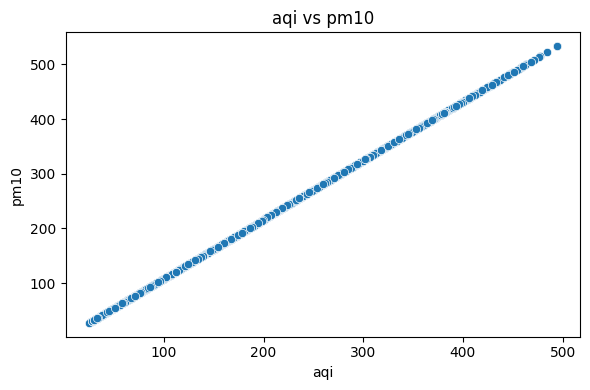

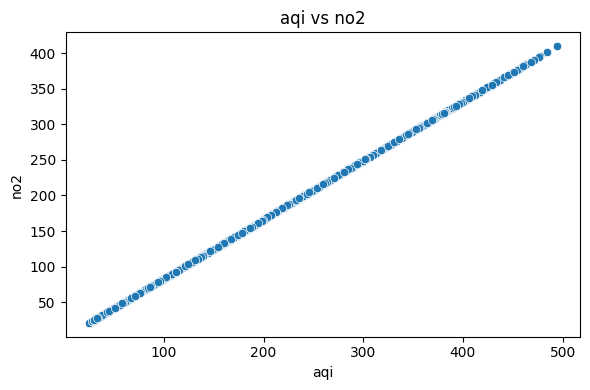

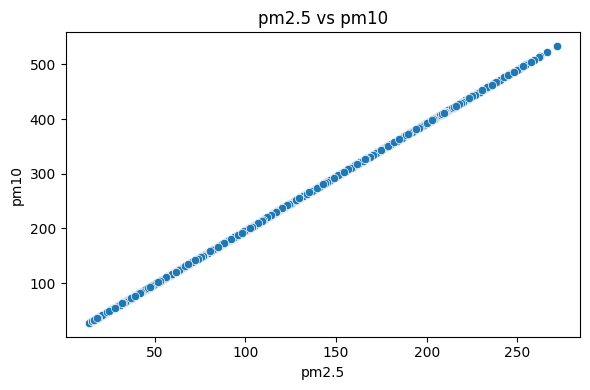

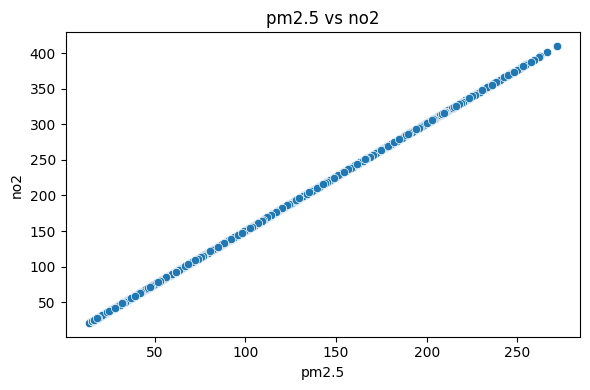

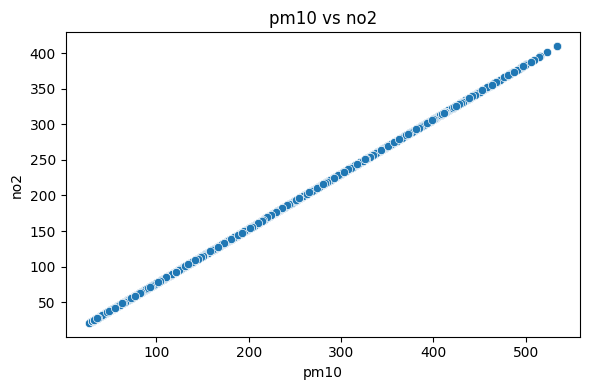

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_excel("master_dataset.xslx.xlsx")

print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

# -----------------------------
# 1. Correlation Matrix
# -----------------------------
corr_matrix = df.corr(numeric_only=True)

print("\nCorrelation Matrix:\n", corr_matrix)

# -----------------------------
# 2. Heatmap
# -----------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Master Dataset)")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Scatter Plot Matrix (Pairplot)
# -----------------------------
numeric_df = df.select_dtypes(include=['number'])

sample_df = numeric_df.sample(n=500, random_state=42) if len(numeric_df) > 500 else numeric_df

sns.pairplot(sample_df)
plt.suptitle("Scatter Plot Matrix (Sampled Data)", y=1.02)
plt.show()

# -----------------------------
# 4. Focused Scatter Plots
# -----------------------------
important_cols = numeric_df.columns[:4]

for i in range(len(important_cols)):
    for j in range(i+1, len(important_cols)):
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=df, x=important_cols[i], y=important_cols[j])
        plt.title(f"{important_cols[i]} vs {important_cols[j]}")
        plt.tight_layout()
        plt.show()

# -----------------------------
# 5.Correlation with Target
# -----------------------------
target_col = 'AQI'

if target_col in df.columns:
    corr_target = corr_matrix[target_col].sort_values(ascending=False)
    print(f"\nCorrelation with {target_col}:\n", corr_target)